# Finite-Sample Adequacy and Robustness of Null Distributions
## Experiment Notebook (10 Hypothesis Tests)

This notebook reproduces all simulation results and figures from the paper. It imports functions from `experiments.py` and runs three studies:

| Study | Research Question | Description |
|-------|------------------|-------------|
| **Study 1** | RQ1: Finite-sample adequacy | Sweep sample size $n \in \{5,...,500\}$ under $H_0$; measure KS distance, KL divergence, and empirical Type I error rate |
| **Study 2** | RQ2: Robustness | Fix $n=50$; violate assumptions (non-normality, variance heterogeneity, unbalanced design, small expected frequencies) |
| **Study 3** | RQ3: MC precision | Fix $n=50$; vary MC replications $N \in \{100,...,50000\}$; measure CV of Type I error across 30 independent runs |

**Tests included:** Student's t (T1), ANOVA (T2), Kruskal-Wallis (T3), Pearson's $\chi^2$ GOF (T4), Bartlett (T5), Fligner-Killeen (T6), Sign test (T7), Cochran's Q (T8), Median test (T9), Hotelling's $T^2$ (T10).

## Setup

Import dependencies and experiment functions from `experiments.py`. All test statistic generators, divergence measures (KS, KL, Type I error), and study runners are defined there.

In [6]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10, 'figure.dpi': 150, 'figure.figsize': (12, 6)})

import importlib
import experiments as exp
importlib.reload(exp)

print('Setup complete. HAS_MPL =', exp.HAS_MPL)

Setup complete. HAS_MPL = True


## Study 1: Finite-Sample Convergence (RQ1)

For each of the 10 tests, generate data under $H_0$ across sample sizes $n \in \{5, 10, 20, 30, 50, 100, 200, 500\}$ with $N = 10{,}000$ MC replications per configuration.

**Metrics:** KS distance (global distributional fit), KL divergence (density-level fit), and empirical Type I error rate (tail accuracy at $\alpha = 0.05$).

**Key finding:** Exact tests (t, ANOVA, Bartlett, sign, Hotelling) show uniformly small KS distances at all $n$; the median test has the slowest convergence among asymptotic tests.

STUDY 1: Finite-sample convergence

  Student t... (0.4s)

  ANOVA F... (0.8s)

  Kruskal-Wallis... (3.2s)

  Chi-sq GOF... (0.3s)

  Bartlett... (0.6s)

  Fligner-Killeen... (6.5s)

  Sign test... (0.2s)

  Cochran Q... (0.8s)

  Median test... (2.0s)

  Hotelling T2... (1.6s)

--- Study 1 Results: Type I Error Rate ---
Test                     n=5    n=10    n=20    n=30    n=50   n=100   n=200   n=500
------------------------------------------------------------------------------------
Student t             0.0543  0.0540  0.0519  0.0523  0.0509  0.0487  0.0526  0.0499
ANOVA F               0.0502  0.0566  0.0515  0.0515  0.0522  0.0559  0.0503  0.0452
Kruskal-Wallis        0.0413  0.0435  0.0459  0.0519  0.0485  0.0498  0.0516  0.0484
Chi-sq GOF            0.0451  0.0523  0.0493  0.0499  0.0512  0.0492  0.0471  0.0491
Bartlett              0.0485  0.0514  0.0505  0.0531  0.0523  0.0528  0.0502  0.0499
Fligner-Killeen       0.0003  0.0317  0.0370  0.0417  0.0387  0.0413  0.0473  0.04

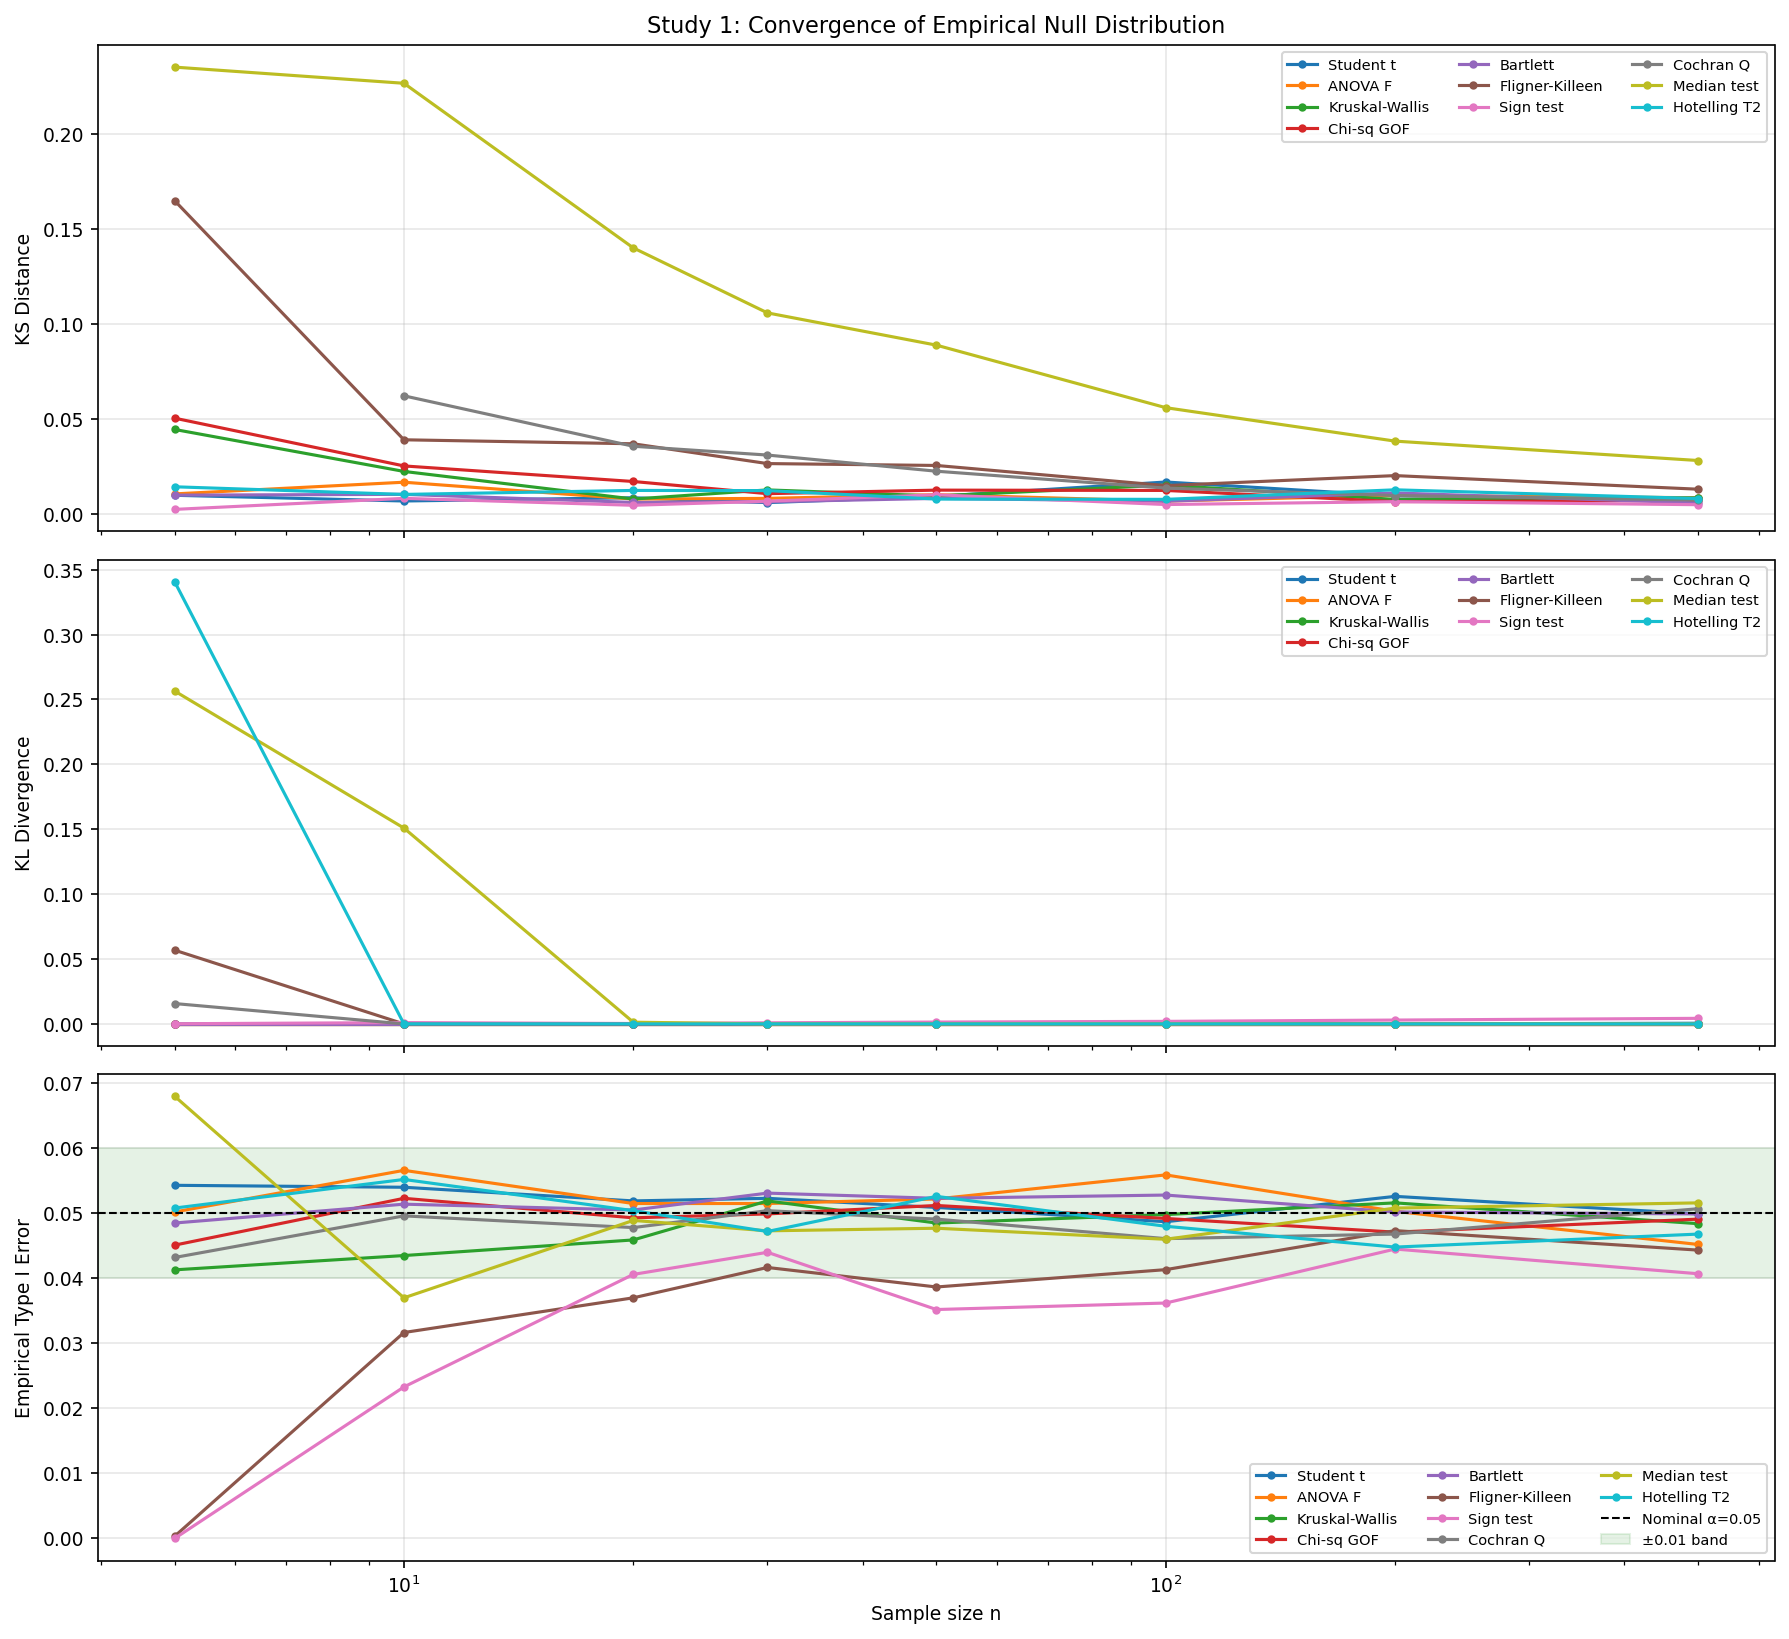

  Saved fig_study1_convergence.png


In [7]:
s1_results, n_star = exp.run_study1(N_mc=10000)

## Study 2: Robustness Under Assumption Violations (RQ2)

Fix $n = 50$ and systematically violate assumptions:

- **Non-normality (skewed):** Replace $N(0,1)$ with $\text{Exp}(1) - 1$ — affects T1, T2, T5, T10
- **Non-normality (heavy-tailed):** Replace $N(0,1)$ with $t(5)$ — affects T1, T2, T5, T10
- **Variance heterogeneity:** $\sigma_1^2 = 1, \sigma_k^2 = 4$ — affects T2, T3, T9
- **Unbalanced design:** Group sizes in ratio 1:2:3 — affects T2, T3, T5, T6, T8, T9

**Key finding:** Bartlett's test inflates to $\hat{\alpha} = 0.422$ under skewness (8.8$\times$ nominal); Fligner-Killeen inflates to only 0.105 (2.1$\times$).


STUDY 2: Robustness under assumption violations

  Student t... (0.0s)

  ANOVA F... (0.3s)

  Kruskal-Wallis... (0.7s)

  Chi-sq GOF... (0.0s)

  Bartlett... (0.3s)

  Fligner-Killeen... (2.7s)

  Sign test... (0.0s)

  Cochran Q... (0.0s)

  Median test... (0.4s)

  Hotelling T2... (0.3s)

--- Study 2 Results: Empirical Type I Error (α=0.05) ---
Test                    baseline      skewed  heavy_tail  hetero_var  unbalanced
--------------------------------------------------------------------------------
Student t                 0.0525      0.0671      0.0470           —           —
ANOVA F                   0.0520      0.0466      0.0512      0.0591      0.0516
Kruskal-Wallis            0.0516      0.0436      0.0490      0.0580      0.0524
Chi-sq GOF                0.0513           —           —           —           —
Bartlett                  0.0497     0.4270*     0.2808*           —      0.0528
Fligner-Killeen           0.0487     0.1090*      0.0543           —      0.0517
S

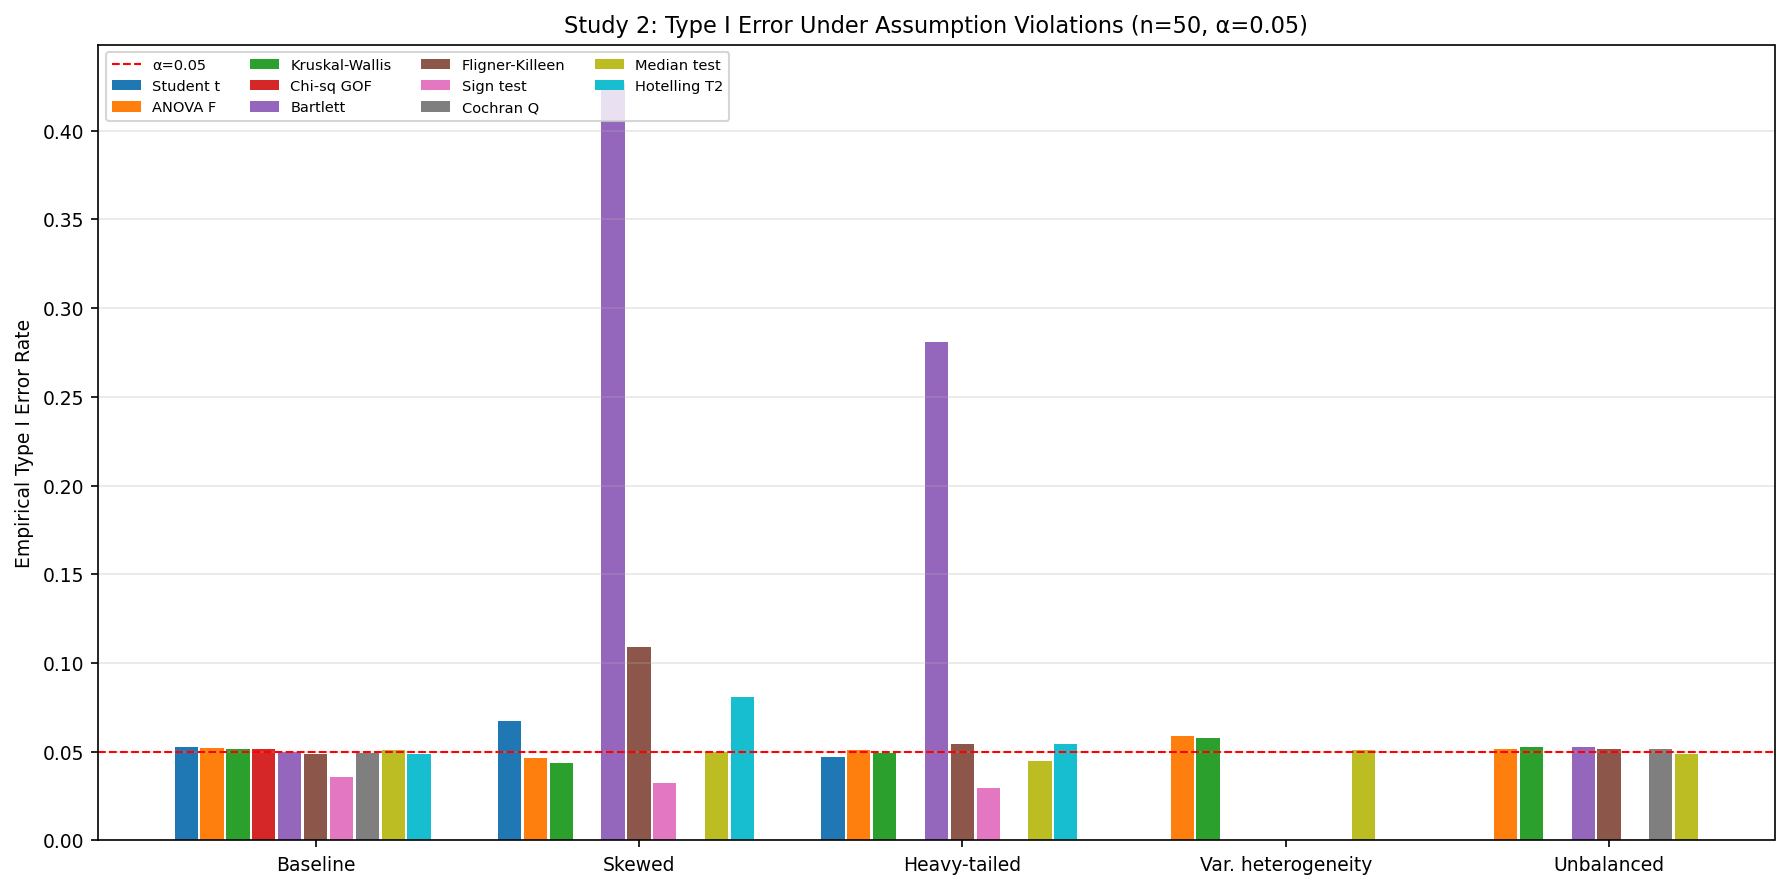

  Saved fig_study2_robustness.png


In [8]:
s2_results = exp.run_study2(N_mc=10000, n_fixed=50)

## Study 3: MC Precision Requirements (RQ3)

Fix $n = 50$ and vary MC replications $N \in \{100, 500, 1000, 5000, 10000, 50000\}$. For each $N$, repeat 30 independent runs and compute the coefficient of variation (CV) of $\hat{\alpha}$.

**Criterion:** $N^*$ = smallest $N$ for which $\text{CV}(\hat{\alpha}) < 0.10$.

**Key finding:** Tests with simple continuous statistics (t, ANOVA, K-W) achieve $N^* = 1{,}500$; the sign test requires $N^* = 5{,}000$ due to discreteness.


STUDY 3: MC precision requirements

  Student t... (1.2s)

  ANOVA F... (3.7s)

  Kruskal-Wallis... (19.2s)

  Chi-sq GOF... (0.7s)

  Bartlett... (3.7s)

  Fligner-Killeen... (151.3s)

  Sign test... (0.9s)

  Cochran Q... (4.8s)

  Median test... (10.7s)

  Hotelling T2... (12.1s)

--- Study 3 Results: CV of Type I Error ---
Test                N=100     N=500    N=1000    N=1500    N=2000    N=3000    N=5000   N=10000   N=50000
---------------------------------------------------------------------------------------------------------
Student t          0.4626    0.2006    0.1617    0.1186    0.1169    0.0821    0.0644    0.0493    0.0214
ANOVA F            0.5873    0.1862    0.1024    0.0818    0.1149    0.0796    0.0644    0.0355    0.0216
Kruskal-Wallis     0.4746    0.2092    0.1287    0.0923    0.0932    0.0769    0.0502    0.0464
Chi-sq GOF         0.4099    0.1815    0.1454    0.1221    0.1075    0.0971    0.0523    0.0368    0.0159
Bartlett           0.3981    0.1508    0.164

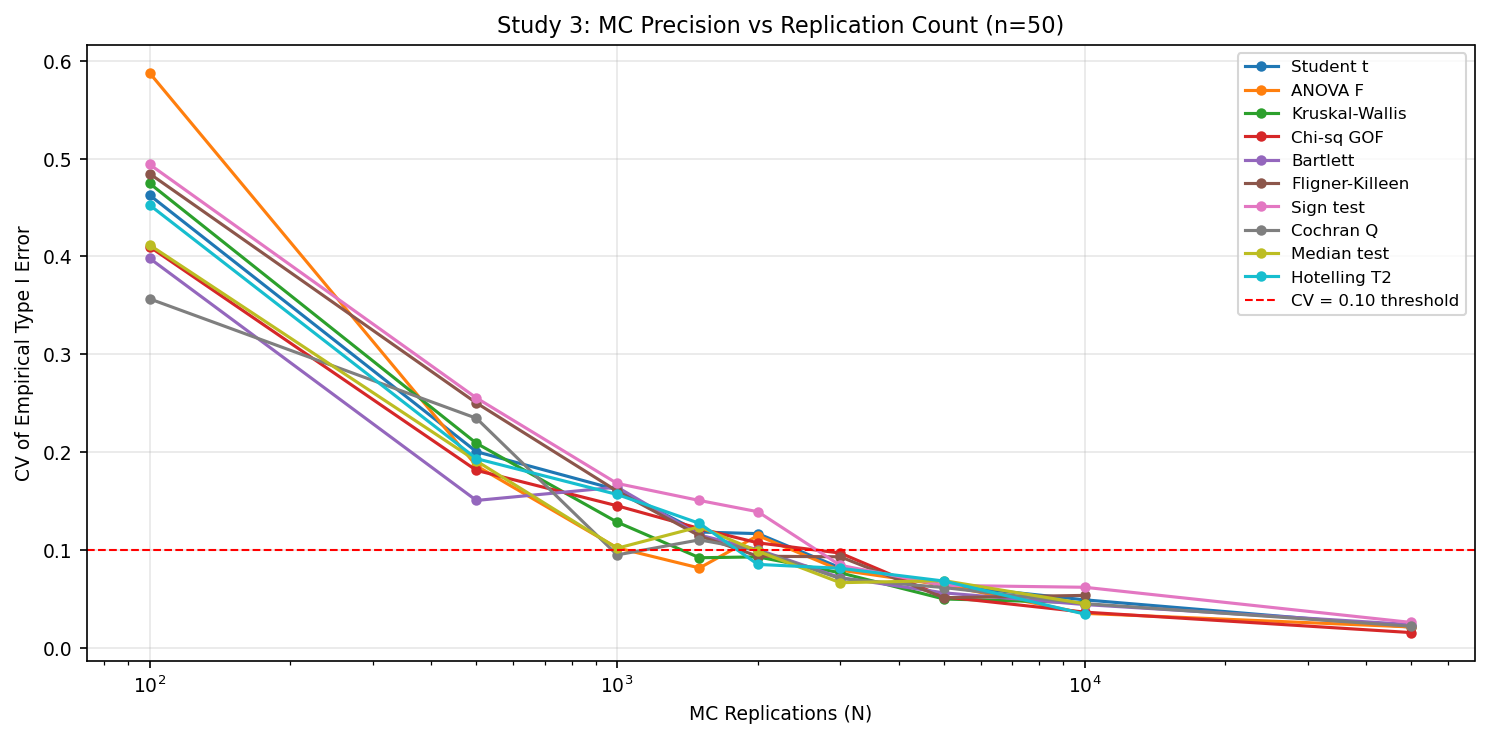

  Saved fig_study3_precision.png


In [9]:
s3_results, n_star_mc = exp.run_study3(n_fixed=50, n_repeats=30)

## Save Results

Export all results to `experiment_results.json` for use in the paper.

In [11]:
import json, os, numpy as np

all_results = {
    'study1': {k: {kk: [float(x) if not np.isnan(x) else None for x in vv]
                    if isinstance(vv, list) else vv
                    for kk, vv in v.items()}
               for k, v in s1_results.items()},
    'study1_nstar': {k: str(v) for k, v in n_star.items()},
    'study2': {k: {kk: float(vv) if not np.isnan(vv) else None
                    for kk, vv in v.items()}
               for k, v in s2_results.items()},
    'study3': {k: v for k, v in s3_results.items()},
    'study3_nstar_mc': {k: str(v) for k, v in n_star_mc.items()},
}

out_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'experiment_results.json')
with open('experiment_results.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)
print('Results saved to experiment_results.json')

Results saved to experiment_results.json
